# Submission Proyek Pertama Machine Terapan: Klasifikasi Bank Customer Churn
- **Nama:** Thomas Dito Rigorastio
- **Email:** B244019E@devacademy.id
- **ID Dicoding:** B244019E

# Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

# Data Wrangling

## 1. Load Data

In [2]:
# load data
df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 2. Assessing and Cleaning

In [3]:
# menampilkan basic info dari df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [4]:
# melihat missing value

df.isna().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [5]:
# melihat duplikasi data dan ringkasan statistik
print("jumlah duplikasi data: ", df.duplicated().sum())
df.describe()

jumlah duplikasi data:  0


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


insight:
- dataset dimuat dan dimasukan ke dataframe df pada tahapan ini
- kemudian telah dilakukan pengecekan terhadap info basic, duplikasi data, missing value, dan parameter statistik
- dari hasil pengecekan, ternyata dataset sudahlah sangat bersih, tidak terdapat adanya missing value, duplikasi data, dan ringkasan statistiknya pun terlihat cukup masuk akal

# EDA

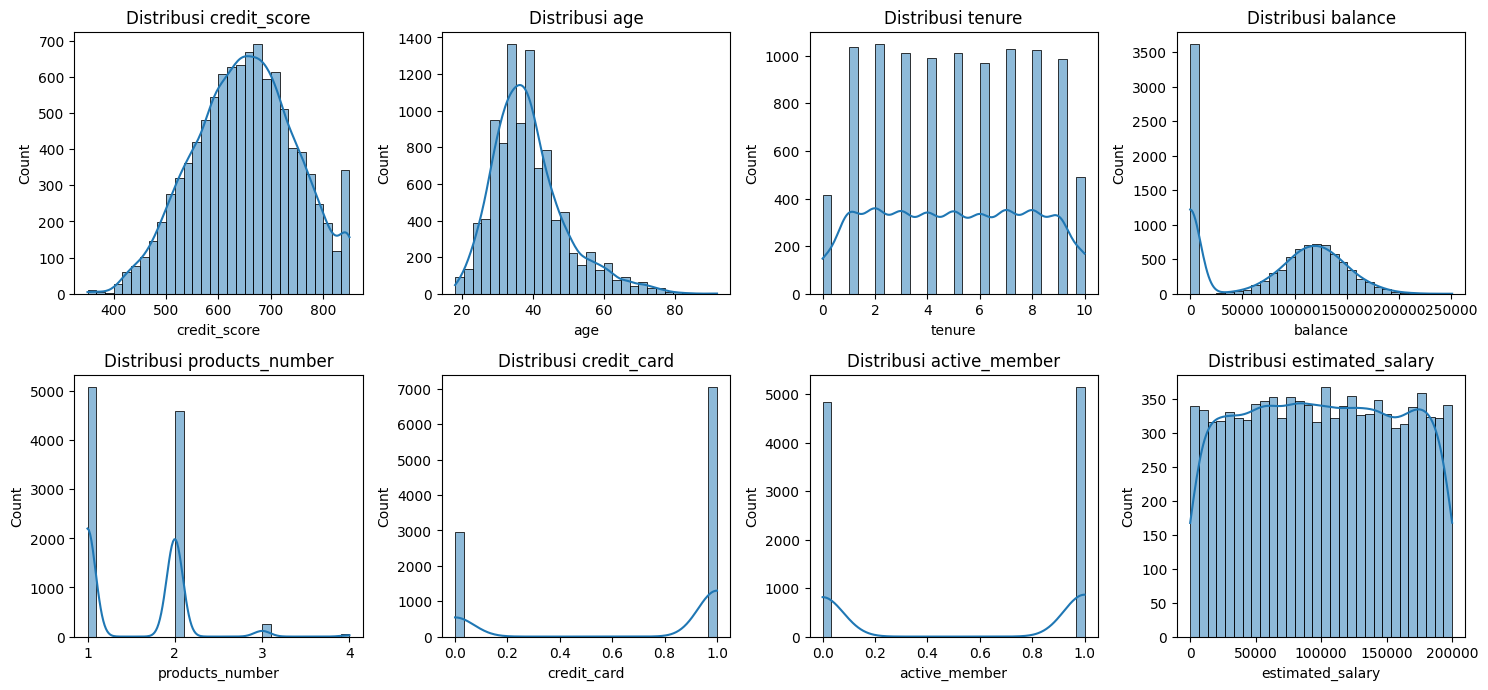

In [6]:
# Plot distribusi data untuk kolom numerik
numerical_columns = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

insight:
- credit_score cendrung berbentuk normal, berarti tidak ada ketimpangan dalam skor kredit pelanggan.
- age memiliki puncak di usia tertentu, berarti mayoritas pelanggan berada dalam rentang usia itu.
- ada banyak pelanggan dengan saldo nol, ini bisa menjadi perhatian, karena pelanggan dengan saldo rendah cenderung churn.
- pada estimated salary terlihat distribusi merata, berarti gaji pelanggan tersebar luas dan tidak terfokus pada rentang tertentu

In [7]:
# Menampilkan jumlah nilai unik pada kolom kategorik
categorical_columns = ['country', 'gender']
for col in categorical_columns:
    print(f"\nJumlah nilai unik pada kolom {col}:")
    print(df[col].value_counts())


Jumlah nilai unik pada kolom country:
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Jumlah nilai unik pada kolom gender:
gender
Male      5457
Female    4543
Name: count, dtype: int64


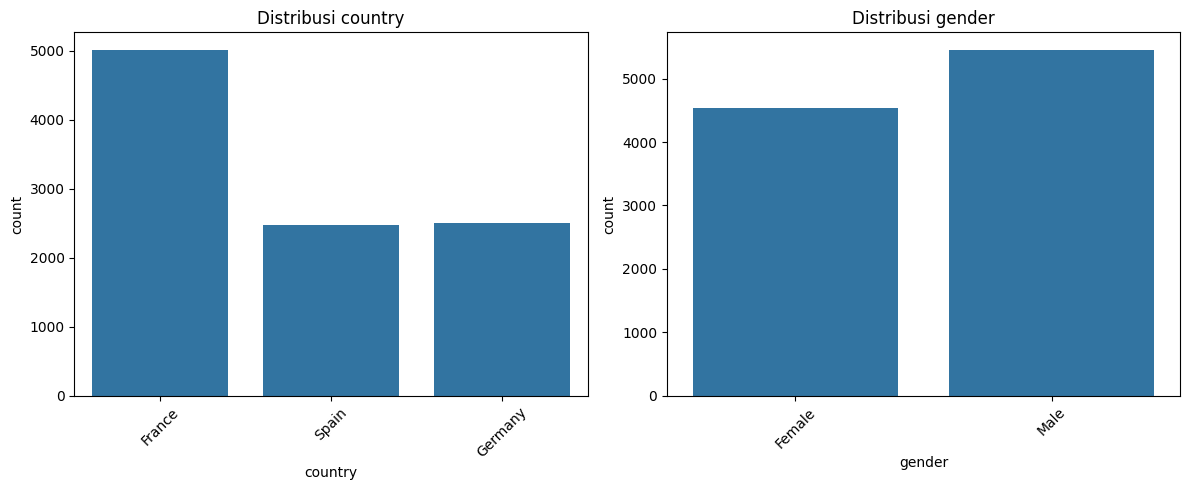

In [8]:
# Plot distribusi data untuk kolom kategorik
categorical_columns = ['country', 'gender']

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(1, 2, i)
    sns.countplot(x=df[col])
    plt.title(f'Distribusi {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

insight:
- ada negara yang mendominasi (lebih banyak pelanggan dari Prancis), ini bisa memengaruhi keputusan segmentasi.
- jika negara tertentu memiliki lebih banyak pelanggan churn, bisa ada faktor spesifik yang menyebabkan hal ini.
- tidak ada perbedaan signifikan antara jumlah pria dan wanita, kemungkinan gender tidak terlalu mempengaruhi pelanggan yang churn.

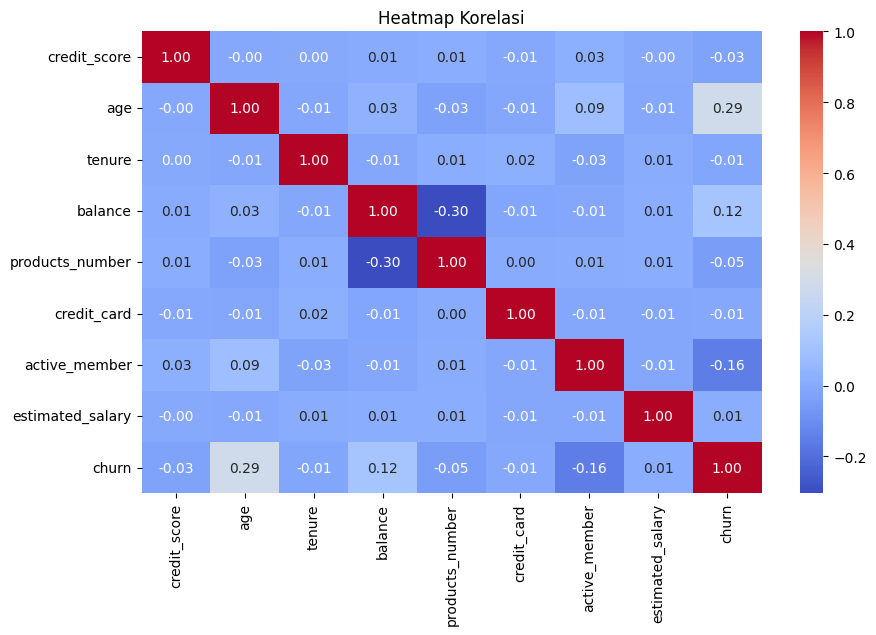

In [9]:
# Plot heatmap korelasi kolom numerik
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_columns + ['churn']].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi")
plt.show()

insight:
- dari hasil heatmap korelasi ini, terlihat bahwa ada beberapa kolom yang memiliki korelasi dengan churn yang menjadi target dari klasifikasi
- age memiliki korelasi sedikit tinggi dengan churn, faktor ini mungkin menjadi penentu churn.
- balance tidak berkorelasi kuat, saldo mungkin bukan faktor utama churn.
- products_number berkorelasi negatif dengan churn, artinya semakin banyak produk yang dimiliki pelanggan, semakin kecil kemungkinan mereka churn.

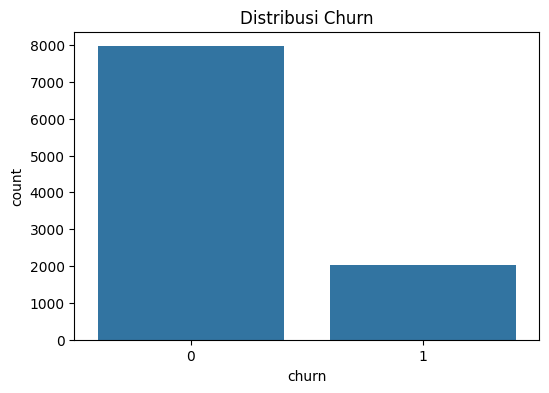

In [10]:
# Plot distribusi kolom churn (target)
plt.figure(figsize=(6,4))
sns.countplot(x=df['churn'])
plt.title("Distribusi Churn")
plt.show()

insight:
- terlihat jumlah pelanggan yang tidak churn masih sangat jauh lebih banyak dibandingkan yang churn
- ini menunjukan masih banyak pelanggan yang menggunakan jasa dari bank ini, namun tetap aware terhadap pelanggan yang churn
- Jika jumlah churn sangat kecil, model prediksi bisa sulit belajar karena ketidakseimbangan data.

# Data Preparation

In [11]:
# label encoding untuk kolom kategorik

categorical_columns = ['country', 'gender']
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Menyimpan encoder jika diperlukan nanti

catatan:
- pada tahap ini, kolom kategorik dilakukan proses label encoding untuk diubah menjadi numerik

In [12]:
# menampilkan df untuk melihat perubahan
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [13]:
# normalisasi kolom numerik menggunakan MinMaxScaler
numerical_columns = ['credit_score', 'country', 'tenure', 'balance', 'products_number', 'estimated_salary']
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# melihat df untuk memastikan hasilnya
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,0.538,0.0,0,42,0.2,0.000000,0.000000,1,1,0.506735,1
1,15647311,0.516,1.0,0,41,0.1,0.334031,0.000000,0,1,0.562709,0
2,15619304,0.304,0.0,0,42,0.8,0.636357,0.666667,1,0,0.569654,1
3,15701354,0.698,0.0,0,39,0.1,0.000000,0.333333,0,0,0.469120,0
4,15737888,1.000,1.0,0,43,0.2,0.500246,0.000000,1,1,0.395400,0


catatan:
- semua kolom bertipe numerik, dilakukan normalisasi menggunakan minmax scaller agar lebih mudah untuk dipelajari oleh model

In [14]:
# data splitting

# memisahkan fitur (X) dan target (y)
X = df.drop(columns=['customer_id', 'churn'])  # Hapus customer_id karena tidak relevan
y = df['churn']

# splitting data menjadi train (80%) dan test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# cek ukuran data setelah split
print(f"Ukuran data training: {X_train.shape}")
print(f"Ukuran data testing: {X_test.shape}")

Ukuran data training: (8000, 10)
Ukuran data testing: (2000, 10)


In [15]:
# Menghitung panjang/jumlah data
print("Jumlah data: ", len(X))
# Menghitung panjang/jumlah data pada X_train
print("Jumlah data latih: ", len(X_train))
# Menghitung panjang/jumlah data pada X_test
print("Jumlah data test: ", len(X_test))

Jumlah data:  10000
Jumlah data latih:  8000
Jumlah data test:  2000


catatan:
- dataset dibagi kedalam data latih dan data uji dengan rasio 80:20 untuk set data latih dan set data uji

# Pembangunan Model

In [16]:
# 1. Inisialisasi model Random Forest
rf_model = RandomForestClassifier(random_state=42)

# 2. Training model
rf_model.fit(X_train, y_train)

# 3. Prediksi pada training dan test set
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# 4. Evaluasi model
def evaluate_model(y_true, y_pred, dataset_type="Train"):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Evaluasi Model pada {dataset_type} Set:")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("-" * 40)

# Evaluasi pada data training
evaluate_model(y_train, y_train_pred, "Train")

# Evaluasi pada data testing
evaluate_model(y_test, y_test_pred, "Test")


Evaluasi Model pada Train Set:
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000
----------------------------------------
Evaluasi Model pada Test Set:
Accuracy  : 0.8640
Precision : 0.7824
Recall    : 0.4595
F1-score  : 0.5789
----------------------------------------


Penjelasan algoritma yang digunakan:
- saya gunakan algoritma random forest untuk melakukan modeling
- mengapa? karena saya rasa random forest merupakan algoritma terbaik karena merupakan ensemble learning sehingga model lebih kompleks dibanding algoritma klasifikasi lainnya dan diharapkan akan menghasilkan hasil akurasi dan evaluasi dari metriks lainnya yang baik
- terlihat model rf(random forest) yang digunakan dilatih dan diuji pada data train dan test kemudian dievaluasi menggunakan 4 metriks evaluasi seperti hasil di atas
- terlihat hasil dari keempat metriks evaluasi di atas sangat baik pada data latih, namun performanya menurun pada data tes, kemungkinan hal ini terjadi karena adanya indikasi sedikit overfitting. Hal ini diharapkan bisa diperbaiki pada saat proses tuning model menggunakan hyperparameter tuning.

In [17]:
# hyperparameter tuning

# Definisi parameter grid untuk tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# GridSearchCV untuk mencari parameter terbaik
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                            param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

# Menampilkan parameter terbaik
print(f"Best Parameters: {grid_search.best_params_}")

# Membuat model baru dengan parameter terbaik
best_rf_model = RandomForestClassifier(**grid_search.best_params_, random_state=42)
best_rf_model.fit(X_train, y_train)

# Evaluasi ulang model dengan parameter terbaik
y_train_best_pred = best_rf_model.predict(X_train)
y_test_best_pred = best_rf_model.predict(X_test)
evaluate_model(y_train, y_train_best_pred, "Train (Tuned Model)")
evaluate_model(y_test, y_test_best_pred, "Test (Tuned Model)")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Evaluasi Model pada Train (Tuned Model) Set:
Accuracy  : 0.9243
Precision : 0.9499
Recall    : 0.6632
F1-score  : 0.7811
----------------------------------------
Evaluasi Model pada Test (Tuned Model) Set:
Accuracy  : 0.8665
Precision : 0.8070
Recall    : 0.4521
F1-score  : 0.5795
----------------------------------------


insight:
- setelah menggunakan GridSearchCV, didaptkan hasil bahwa parameter terbaik adalah parameter kedua dengan n_estimators=100
- Setelah proses tuning, didapati model sudah tidak lagi mengalami overfitting terlalu jauh pada saat base model, karena hasil evaluasi metriks pada data latih, terlihat tidak rata 100% lagi.
- Namun, tetap hasil recall nya masih rendah, akan tetapi hasil seluruh metriks evaluasinya pada set data tes meningkat dibanding pada base model.

# Model dengan hasil hyperparameter terbaik

In [18]:
# Inisialisasi model dengan hyperparameter terbaik dari tuning
best_rf_model = RandomForestClassifier(
    max_depth=20, 
    min_samples_leaf=2, 
    min_samples_split=10, 
    n_estimators=100, 
    random_state=42
)

# Melatih model dengan data training
best_rf_model.fit(X_train, y_train)

# Melakukan prediksi pada training dan testing set
y_train_best_pred = best_rf_model.predict(X_train)
y_test_best_pred = best_rf_model.predict(X_test)

# Evaluasi model setelah tuning
def evaluate_model(y_true, y_pred, dataset_type="Train"):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Evaluasi Model pada {dataset_type} Set:")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("-" * 40)

# Menampilkan hasil evaluasi model
evaluate_model(y_train, y_train_best_pred, "Train (Tuned Model)")
evaluate_model(y_test, y_test_best_pred, "Test (Tuned Model)")

Evaluasi Model pada Train (Tuned Model) Set:
Accuracy  : 0.9243
Precision : 0.9499
Recall    : 0.6632
F1-score  : 0.7811
----------------------------------------
Evaluasi Model pada Test (Tuned Model) Set:
Accuracy  : 0.8665
Precision : 0.8070
Recall    : 0.4521
F1-score  : 0.5795
----------------------------------------


insight:
- hasil evaluasi model di atas setelah tuning menunjukkan bahwa tuning hyperparameter meningkatkan performa model, khususnya pada hasil accuracy dan precision pada set data tes yang meningkat sedikit dari pada base model.
- Namun, hasil recall cukup rendah, yang berarti hanya 45.21% dari pelanggan yang benar-benar churn berhasil dikenali.
- Nilai pada F1-score di angka 57.95% menunjukkan model cukup baik, tapi recall masih bisa ditingkatkan.

# Evaluasi Model

In [19]:
# Membuat perbandingan hasil evaluasi sebelum dan setelah tuning

# Evaluasi model sebelum tuning
accuracy_train = accuracy_score(y_train, y_train_pred)
f1_train = f1_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred)
recall_train = recall_score(y_train, y_train_pred)

accuracy_test = accuracy_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)

# Evaluasi model setelah tuning
accuracy_train_best = accuracy_score(y_train, y_train_best_pred)
f1_train_best = f1_score(y_train, y_train_best_pred)
precision_train_best = precision_score(y_train, y_train_best_pred)
recall_train_best = recall_score(y_train, y_train_best_pred)

accuracy_test_best = accuracy_score(y_test, y_test_best_pred)
f1_test_best = f1_score(y_test, y_test_best_pred)
precision_test_best = precision_score(y_test, y_test_best_pred)
recall_test_best = recall_score(y_test, y_test_best_pred)

# Menyusun perbandingan hasil evaluasi sebelum dan setelah tuning
pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall",  "F1-Score"],
    "Before Tuning - Training": [accuracy_train, precision_train, recall_train, f1_train],
    "Before Tuning - Testing": [accuracy_test, precision_test, recall_test, f1_test],
    "After Tuning - Training": [accuracy_train_best, precision_train_best, recall_train_best, f1_train_best],
    "After Tuning - Testing": [accuracy_test_best, precision_test_best, recall_test_best, f1_test_best]
})

,Metric,Before Tuning - Training,Before Tuning - Testing,After Tuning - Training,After Tuning - Testing
0,Accuracy,1.0,0.864000,0.924250,0.866500
1,Precision,1.0,0.782427,0.949912,0.807018
2,Recall,1.0,0.459459,0.663190,0.452088
3,F1-Score,1.0,0.578947,0.781069,0.579528


ANALISIS HASIL EVALUASI MODEL:
1. Perbandingan hasil evaluasi sebelum dan setelah tuning pada set data test:
* Sebelum tuning:
  - Accuracy (Testing): 86.40%
  - Precision (Testing): 78.24%
  - Recall (Testing): 45.95%
  - F1-Score (Testing): 57.89%
* Setelah tuning:
  - Accuracy (Testing): 86.65%
  - Precision (Testing): 80.70%
  - Recall (Testing): 45.21%
  - F1-Score (Testing): 57.95%
* Kesimpulan:
Hasil evaluasi menunjukan bahwa tuning hyperparameter meningkatkan sedikit performa model, khususnya pada accuracy dan precision yang meningkat cukup baik dengan nilai keduanya di atas 80%, yang berarti model mampu mengenali pelanggan churn dan non-churn dengan baik secara umum/keseluruhan. Precision (0.8070 pada test set) berarti dari seluruh prediksi churn, 80.70% benar-benar churn. Recall (0.4595 pada test set) menunjukkan bahwa model hanya dapat mengenali 45.95% pelanggan yang benar-benar churn, yang cukup rendah. F1-score (0.5795 pada test set) mengindikasikan bahwa keseimbangan antara precision dan recall masih belum optimal. Masalah utama di sini adalah rendahnya recall. Ini berarti banyak pelanggan yang benar-benar churn tetapi tidak berhasil diprediksi oleh model.

2. Identifikasi Kelemahan Model:
- Precision atau Recall:
  - Hasil precision (0.8070 pada test set) berarti dari seluruh prediksi churn, 80.70% benar-benar churn.
  - Namun, recall (0.4595 pada test set) menunjukkan bahwa model hanya dapat mengenali 45.95% pelanggan yang benar-benar churn, yang cukup rendah.

- Overfitting atau Underfitting?
  - Overfitting: 
    - Kemungkinan pertama -> model mengalami sedikit overfitting, karena model sangat baik pada data uji dengan nilai metriks rata 100% pada semua metriks evaluasi, sedangkan pada data uji model mengalami penurunan. Namun, hasilnya tidak cukup jauh dan masih bisa dibilang baik karena pada accuracy senilai 86% dan 81% pada precision. Namun, setelah dilakukan hyperparameter tuning, terlihat pada data latih hasil keempat metriks sudah tidak rata 100%, yang mengindikasikan model sudah tidak terlalu mengalami overfitting. Mungkin terdapat kesalahan pada proses data preparation.
    - Kemungkinan kedua -> model mengalami sedikit overfitting karena jumlah churn sangat kecil dibandingkan dengan jumlah yang tidak churn pada kolom churn di dataset, sehingga model prediksi bisa sulit belajar karena ketidakseimbangan data.

  - Underfitting: Tidak terjadi underfitting karena akurasi model sangat tinggi pada saat pelatihan.

3. Rekomendasi Lanjutan:
- Model memiliki akurasi dan precision tinggi, yang berarti cukup baik dalam memprediksi pelanggan churn dengan tingkat kesalahan rendah. Namun, recall masih rendah (45.21%), yang berarti masih ada banyak pelanggan churn yang tidak terdeteksi. Sehingga, mungkin untuk rekomendasi lanjutannya bisa eksplor menggunakan algoritma yang lainnya seperti gradient boosting atau algoritma klasifikasi yang lainnya, untuk siapa tahu mendapatkan hasil yang lebih memuaskan.